# Entrenamiento de Redes Neuronales **sin Backpropagation**
## Optimización por Enjambre de Partículas (PSO)

**Curso:** Inteligencia Artificial / Computación Bioinspirada  
**Equipo:** _(completar)_ · **Entorno:** Google Colab · **Lenguaje:** Python 3 + NumPy

---

### Problema

Entrenar un perceptrón multicapa de **3 capas de pesos** (`entrada → oculta₁ → oculta₂ → salida`)
hallando **todos los pesos y bias** mediante un algoritmo de enjambre, **sin calcular ni una sola derivada**.

Formalmente, si $\theta \in \mathbb{R}^D$ es el vector con todos los parámetros de la red,
buscamos

$$\theta^{*} = \arg\min_{\theta \in [\ell,u]^D} \; J(\theta), \qquad
J(\theta) = \underbrace{-\frac{1}{N}\sum_{i=1}^{N}\big[y_i\log \hat y_i + (1-y_i)\log(1-\hat y_i)\big]}_{\text{entropía cruzada}} \;+\; \lambda\|\theta\|^2$$

donde $\hat y_i = f(x_i;\theta)$ es la salida de la red. PSO trata a $J$ como una **caja negra**:
solo necesita evaluarla, nunca $\nabla J$.

### Ciclo del algoritmo de enjambre cubierto en este notebook

| # | Etapa | Dónde se implementa |
|---|-------|---------------------|
| 1 | Representación de la partícula | `MLP.unpack()` — vector plano ↔ (W, b) |
| 2 | Inicialización del enjambre | `PSO._initialize_swarm()` |
| 3 | Función de aptitud | `bce_fitness()` / `cce_fitness()` |
| 4 | Comportamiento de la partícula | `PSO._update_velocity()` / `_update_position()` |
| 5 | Evolución | bucle principal de `PSO.optimize()` |
| 6 | Finalización | `PSO._should_stop()` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_moons, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.dpi": 120, "font.size": 9})
np.set_printoptions(precision=4, suppress=True)
print("numpy", np.__version__)

numpy 2.1.3


---
## 1 · Representación de la partícula

> **Idea central.** Una partícula **es** una red neuronal. Concatenamos todas las matrices
> de pesos y todos los vectores de bias en un único vector $\theta \in \mathbb{R}^D$.
> La posición de la partícula en el espacio de búsqueda *es* la configuración de la red.

Para la arquitectura `2 → 8 → 6 → 1`:

$$D = \underbrace{(2\cdot 8 + 8)}_{24} + \underbrace{(8\cdot 6 + 6)}_{54} + \underbrace{(6\cdot 1 + 1)}_{7} = 85$$

Es decir, el enjambre navega un espacio continuo de **85 dimensiones**.

Primero las activaciones, y luego la red — que solo sabe hacer *forward pass*.

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -60, 60)))


def tanh(z):
    return np.tanh(z)


def relu(z):
    return np.maximum(0.0, z)


def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


ACTIVATIONS = {"sigmoid": sigmoid, "tanh": tanh, "relu": relu, "softmax": softmax}

In [3]:
class MLP:
    """Perceptron multicapa puramente 'forward'.

    Los pesos NO viven dentro del objeto: se inyectan desde un vector
    plano (la particula). Asi el mismo objeto sirve para evaluar a todo
    el enjambre sin duplicar memoria.
    """

    def __init__(self, layer_sizes, hidden_activation="tanh", output_activation="sigmoid"):
        self.layer_sizes = list(layer_sizes)          # p.ej. [2, 8, 6, 1]
        self.hidden_activation = hidden_activation
        self.output_activation = output_activation

        # Metadatos para desempaquetar el vector plano -> (W, b) por capa
        self.shapes = []
        self.n_params = 0
        for i in range(len(self.layer_sizes) - 1):
            n_in, n_out = self.layer_sizes[i], self.layer_sizes[i + 1]
            self.shapes.append(((n_in, n_out), (n_out,)))
            self.n_params += n_in * n_out + n_out

    # ---- decodificacion: vector plano -> pesos y bias --------------
    def unpack(self, vector):
        """Convierte la particula (vector 1-D) en la lista [(W1,b1), ...]."""
        params, idx = [], 0
        for (w_shape, b_shape) in self.shapes:
            n_w = w_shape[0] * w_shape[1]
            W = vector[idx: idx + n_w].reshape(w_shape)
            idx += n_w
            n_b = b_shape[0]
            b = vector[idx: idx + n_b].reshape(b_shape)
            idx += n_b
            params.append((W, b))
        return params

    # ---- propagacion hacia adelante --------------------------------
    def forward(self, X, vector):
        params = self.unpack(vector)
        h_act = ACTIVATIONS[self.hidden_activation]
        o_act = ACTIVATIONS[self.output_activation]
        A = X
        for k, (W, b) in enumerate(params):
            Z = A @ W + b
            A = o_act(Z) if k == len(params) - 1 else h_act(Z)
        return A

    def describe(self):
        txt = " -> ".join(str(s) for s in self.layer_sizes)
        return (f"MLP {txt} | activacion oculta={self.hidden_activation} | "
                f"salida={self.output_activation} | parametros (dimension del "
                f"problema) = {self.n_params}")

In [4]:
demo = MLP([2, 8, 6, 1], "tanh", "sigmoid")
print(demo.describe())

# Una partícula aleatoria = una red aleatoria
p = np.random.default_rng(0).uniform(-1, 1, demo.n_params)
print("\nPartícula (primeros 10 genes):", p[:10])
W1, b1 = demo.unpack(p)[0]
print("Se decodifica en W1", W1.shape, "b1", b1.shape, "... etc.")
print("Salida de la red para 3 patrones:", demo.forward(np.random.randn(3, 2), p).ravel())

MLP 2 -> 8 -> 6 -> 1 | activacion oculta=tanh | salida=sigmoid | parametros (dimension del problema) = 85

Partícula (primeros 10 genes): [ 0.2739 -0.4604 -0.9181 -0.9669  0.6265  0.8255  0.2133  0.459   0.0872
  0.8701]
Se decodifica en W1 (2, 8) b1 (8,) ... etc.
Salida de la red para 3 patrones: [0.6306 0.647  0.602 ]


---
## 2 · Función de aptitud (fitness)

La aptitud mide **qué tan buena es la red codificada por la partícula**. Usamos entropía cruzada
sobre el conjunto de entrenamiento más un término L2 que penaliza pesos grandes (actúa como
regularizador y evita que el enjambre se escape a los bordes del dominio).

Es un problema de **minimización**: menor fitness = mejor partícula.

In [5]:
def bce_fitness(vector, net, X, y, l2=1e-4):
    """Entropia cruzada binaria + regularizacion L2 (penalizacion)."""
    p = np.clip(net.forward(X, vector).ravel(), 1e-9, 1 - 1e-9)
    loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    return loss + l2 * np.mean(vector ** 2)


def cce_fitness(vector, net, X, Y_onehot, l2=1e-4):
    """Entropia cruzada categorica (multiclase, salida softmax)."""
    P = np.clip(net.forward(X, vector), 1e-9, 1.0)
    loss = -np.mean(np.sum(Y_onehot * np.log(P), axis=1))
    return loss + l2 * np.mean(vector ** 2)


def accuracy_binary(vector, net, X, y, thr=0.5):
    p = net.forward(X, vector).ravel()
    return float(np.mean((p >= thr).astype(int) == y))


def accuracy_multiclass(vector, net, X, y_idx):
    P = net.forward(X, vector)
    return float(np.mean(P.argmax(axis=1) == y_idx))

---
## 3 · El enjambre: inicialización, comportamiento, evolución y finalización

**Comportamiento de la partícula.** En cada iteración $t$, la partícula $i$ actualiza su
velocidad combinando tres fuerzas:

$$v_i^{t+1} = \underbrace{w\,v_i^{t}}_{\text{inercia}} + \underbrace{c_1 r_1 (p_i - x_i^{t})}_{\text{componente cognitiva}} + \underbrace{c_2 r_2 (g - x_i^{t})}_{\text{componente social}}$$
$$x_i^{t+1} = x_i^{t} + v_i^{t+1}$$

- $p_i$ = mejor posición histórica de **esa** partícula (memoria individual)
- $g$ = mejor posición encontrada por **todo** el enjambre (memoria colectiva)
- $r_1, r_2 \sim U(0,1)^D$ dan la estocasticidad

**Inercia decreciente** $w: 0.9 \rightarrow 0.4$ hace que el enjambre explore al principio y
explote (refine) al final.

**Criterios de parada (finalización):** máximo de iteraciones, aptitud objetivo alcanzada, o
estancamiento del *gbest* durante `patience` iteraciones.

In [6]:
class PSO:
    """PSO estandar con inercia decreciente, clamping de velocidad y
    reinicio de particulas estancadas.

    Ciclo implementado (los 6 puntos del enunciado):
      (1) representacion de la particula  -> vector R^D = pesos+bias
      (2) inicializacion del enjambre     -> _initialize_swarm()
      (3) funcion de aptitud              -> self.fitness_fn
      (4) comportamiento de la particula  -> _update_velocity/_update_position
      (5) evolucion                       -> bucle de optimize()
      (6) finalizacion                    -> _should_stop()
    """

    def __init__(
        self,
        dim,
        fitness_fn,
        n_particles=40,
        bounds=(-2.0, 2.0),
        w_max=0.9,
        w_min=0.4,
        c1=1.7,          # coeficiente cognitivo (memoria propia)
        c2=1.7,          # coeficiente social (memoria del enjambre)
        v_frac=0.2,      # |v_max| = v_frac * (rango de busqueda)
        max_iter=300,
        tol=1e-6,
        patience=60,     # paradas por estancamiento
        reinit_patience=25,
        seed=None,
        verbose_every=0,
    ):
        self.dim = dim
        self.fitness_fn = fitness_fn
        self.n_particles = n_particles
        self.lb, self.ub = bounds
        self.w_max, self.w_min = w_max, w_min
        self.c1, self.c2 = c1, c2
        self.v_max = v_frac * (self.ub - self.lb)
        self.max_iter = max_iter
        self.tol = tol
        self.patience = patience
        self.reinit_patience = reinit_patience
        self.rng = np.random.default_rng(seed)
        self.verbose_every = verbose_every

        # historial para el informe
        self.history = {"gbest": [], "mean": [], "diversity": [], "w": []}

    # ---------- (2) INICIALIZACION DEL ENJAMBRE ---------------------
    def _initialize_swarm(self):
        # Posiciones: uniforme en el hipercubo de busqueda.
        self.X = self.rng.uniform(self.lb, self.ub, size=(self.n_particles, self.dim))
        # Velocidades: pequenas, para no "explotar" en la iteracion 1.
        self.V = self.rng.uniform(-self.v_max, self.v_max,
                                  size=(self.n_particles, self.dim)) * 0.1

        # Memoria individual (pbest) y global (gbest)
        self.pbest = self.X.copy()
        self.pbest_fit = np.array([self.fitness_fn(x) for x in self.X])
        g = int(np.argmin(self.pbest_fit))
        self.gbest = self.pbest[g].copy()
        self.gbest_fit = float(self.pbest_fit[g])

        self.stall = np.zeros(self.n_particles, dtype=int)  # estancamiento individual
        self.global_stall = 0

    # ---------- (4) COMPORTAMIENTO DE LA PARTICULA ------------------
    def _inertia(self, it):
        """Inercia lineal decreciente: exploracion -> explotacion."""
        return self.w_max - (self.w_max - self.w_min) * (it / max(1, self.max_iter - 1))

    def _update_velocity(self, w):
        r1 = self.rng.random((self.n_particles, self.dim))
        r2 = self.rng.random((self.n_particles, self.dim))
        cognitive = self.c1 * r1 * (self.pbest - self.X)
        social = self.c2 * r2 * (self.gbest - self.X)
        self.V = w * self.V + cognitive + social
        np.clip(self.V, -self.v_max, self.v_max, out=self.V)

    def _update_position(self):
        self.X = self.X + self.V
        # Manejo de frontera tipo "pared absorbente": recorta y anula la
        # velocidad en la dimension que se salio del dominio.
        out = (self.X < self.lb) | (self.X > self.ub)
        np.clip(self.X, self.lb, self.ub, out=self.X)
        self.V[out] = 0.0

    def _reinit_stalled(self):
        """Diversidad: particula sin mejorar demasiado tiempo se reinyecta
        cerca del gbest con ruido (no se reinicia a ciegas)."""
        idx = np.where(self.stall >= self.reinit_patience)[0]
        for i in idx:
            if i == int(np.argmin(self.pbest_fit)):
                continue  # nunca destruimos a la mejor particula
            self.X[i] = np.clip(
                self.gbest + self.rng.normal(0, 0.5, self.dim), self.lb, self.ub)
            self.V[i] = self.rng.uniform(-self.v_max, self.v_max, self.dim) * 0.1
            self.stall[i] = 0

    # ---------- (6) CRITERIO DE FINALIZACION ------------------------
    def _should_stop(self, it):
        if it >= self.max_iter - 1:
            return True, "maximo de iteraciones alcanzado"
        if self.gbest_fit <= self.tol:
            return True, f"aptitud objetivo alcanzada (<= {self.tol})"
        if self.global_stall >= self.patience:
            return True, f"convergencia: sin mejora en {self.patience} iteraciones"
        return False, ""

    # ---------- (5) EVOLUCION: el bucle principal -------------------
    def optimize(self, callback=None):
        self._initialize_swarm()
        stop_reason = "maximo de iteraciones alcanzado"

        for it in range(self.max_iter):
            w = self._inertia(it)

            self._update_velocity(w)
            self._update_position()

            # Evaluacion de aptitud y actualizacion de memorias
            fit = np.array([self.fitness_fn(x) for x in self.X])
            improved = fit < self.pbest_fit
            self.pbest[improved] = self.X[improved]
            self.pbest_fit[improved] = fit[improved]
            self.stall[improved] = 0
            self.stall[~improved] += 1

            g = int(np.argmin(self.pbest_fit))
            if self.pbest_fit[g] < self.gbest_fit - 1e-12:
                self.gbest = self.pbest[g].copy()
                self.gbest_fit = float(self.pbest_fit[g])
                self.global_stall = 0
            else:
                self.global_stall += 1

            self._reinit_stalled()

            # Registro
            diversity = float(np.mean(np.linalg.norm(self.X - self.X.mean(0), axis=1)))
            self.history["gbest"].append(self.gbest_fit)
            self.history["mean"].append(float(fit.mean()))
            self.history["diversity"].append(diversity)
            self.history["w"].append(float(w))

            if callback is not None:
                callback(it, self)
            if self.verbose_every and (it % self.verbose_every == 0):
                print(f"  iter {it:4d} | gbest={self.gbest_fit:.5f} "
                      f"| media={fit.mean():.5f} | w={w:.3f} | div={diversity:.3f}")

            stop, reason = self._should_stop(it)
            if stop:
                stop_reason = reason
                self.n_iter_ = it + 1
                break
        else:
            self.n_iter_ = self.max_iter

        self.stop_reason_ = stop_reason
        return self.gbest, self.gbest_fit

---
## 4 · Envoltorio estilo `scikit-learn`

In [7]:
class PSOClassifier:
    """Clasificador MLP entrenado 100% con PSO (cero backpropagation)."""

    def __init__(self, hidden=(8, 6), task="binary", seed=0, **pso_kwargs):
        self.hidden = tuple(hidden)
        self.task = task
        self.seed = seed
        self.pso_kwargs = pso_kwargs

    def fit(self, X, y, X_val=None, y_val=None):
        n_in = X.shape[1]
        if self.task == "binary":
            layers = [n_in, *self.hidden, 1]
            self.net = MLP(layers, "tanh", "sigmoid")
            fit_fn = lambda v: bce_fitness(v, self.net, X, y)
        else:
            self.classes_ = np.unique(y)
            n_out = len(self.classes_)
            Y = np.eye(n_out)[y]
            layers = [n_in, *self.hidden, n_out]
            self.net = MLP(layers, "tanh", "softmax")
            fit_fn = lambda v: cce_fitness(v, self.net, X, Y)

        self.pso = PSO(dim=self.net.n_params, fitness_fn=fit_fn,
                       seed=self.seed, **self.pso_kwargs)

        self.val_curve_ = []
        cb = None
        if X_val is not None:
            def cb(it, s):
                self.val_curve_.append(self.score_vec(s.gbest, X_val, y_val))

        self.w_, self.loss_ = self.pso.optimize(callback=cb)
        return self

    def score_vec(self, vec, X, y):
        if self.task == "binary":
            return accuracy_binary(vec, self.net, X, y)
        return accuracy_multiclass(vec, self.net, X, y)

    def predict_proba(self, X):
        return self.net.forward(X, self.w_)

    def predict(self, X):
        P = self.predict_proba(X)
        if self.task == "binary":
            return (P.ravel() >= 0.5).astype(int)
        return P.argmax(axis=1)

    def score(self, X, y):
        return float(np.mean(self.predict(X) == y))

---
## 5 · Experimento 1 — `two moons`, MLP `2-8-6-1`

Problema no linealmente separable: obliga a la red a usar sus capas ocultas.

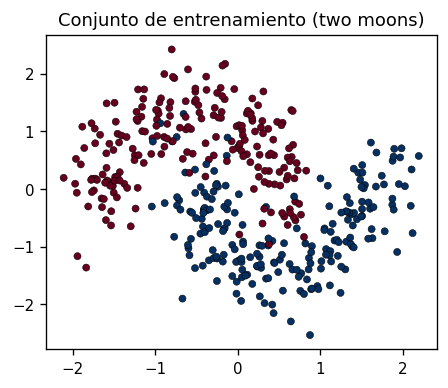

train: (420, 2)  test: (180, 2)


In [8]:
X, y = make_moons(n_samples=600, noise=0.22, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
sc = StandardScaler().fit(Xtr)
Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)

plt.figure(figsize=(4.2, 3.4))
plt.scatter(Xtr[:, 0], Xtr[:, 1], c=ytr, cmap="RdBu", edgecolor="k", s=18, lw=.3)
plt.title("Conjunto de entrenamiento (two moons)"); plt.show()
print("train:", Xtr.shape, " test:", Xte.shape)

In [9]:
clf = PSOClassifier(hidden=(8, 6), task="binary", seed=7,
                    n_particles=40, max_iter=300, bounds=(-2.5, 2.5),
                    w_max=0.9, w_min=0.4, c1=1.7, c2=1.7,
                    patience=80, verbose_every=25)

t0 = time.time()
clf.fit(Xtr, ytr, X_val=Xte, y_val=yte)
t_pso = time.time() - t0

print("\n" + "=" * 60)
print("Dimensión del problema D  :", clf.net.n_params)
print("Criterio de parada        :", clf.pso.stop_reason_,
      f"(iteración {clf.pso.n_iter_})")
print(f"Fitness final (BCE + L2)  : {clf.loss_:.4f}")
print(f"Accuracy entrenamiento    : {clf.score(Xtr, ytr):.4f}")
print(f"Accuracy prueba           : {clf.score(Xte, yte):.4f}")
print(f"Tiempo                    : {t_pso:.2f} s")
print("Evaluaciones de fitness   :", clf.pso.n_iter_ * clf.pso.n_particles)

  iter    0 | gbest=0.43097 | media=1.08005 | w=0.900 | div=9.335
  iter   25 | gbest=0.23130 | media=0.62734 | w=0.858 | div=4.710
  iter   50 | gbest=0.22666 | media=0.54399 | w=0.816 | div=4.431
  iter   75 | gbest=0.21352 | media=0.45378 | w=0.775 | div=3.714
  iter  100 | gbest=0.19893 | media=0.46555 | w=0.733 | div=3.452
  iter  125 | gbest=0.17113 | media=0.36259 | w=0.691 | div=2.953
  iter  150 | gbest=0.15285 | media=0.29341 | w=0.649 | div=2.455
  iter  175 | gbest=0.13540 | media=0.22956 | w=0.607 | div=1.808
  iter  200 | gbest=0.12745 | media=0.20056 | w=0.566 | div=1.520
  iter  225 | gbest=0.12266 | media=0.15931 | w=0.524 | div=1.109
  iter  250 | gbest=0.11868 | media=0.14655 | w=0.482 | div=0.825
  iter  275 | gbest=0.11641 | media=0.11989 | w=0.440 | div=0.206

Dimensión del problema D  : 85
Criterio de parada        : maximo de iteraciones alcanzado (iteración 300)
Fitness final (BCE + L2)  : 0.1149
Accuracy entrenamiento    : 0.9595
Accuracy prueba           : 0.

### Diagnóstico del enjambre

Tres señales que confirman que el enjambre se comporta como debe:
1. **gbest** desciende monótonamente; la **aptitud media** lo persigue → el enjambre se agrupa.
2. La **diversidad** cae junto con $w$ → transición ordenada de exploración a explotación.
3. La **accuracy en test** del gbest sube → no está memorizando, está aprendiendo.

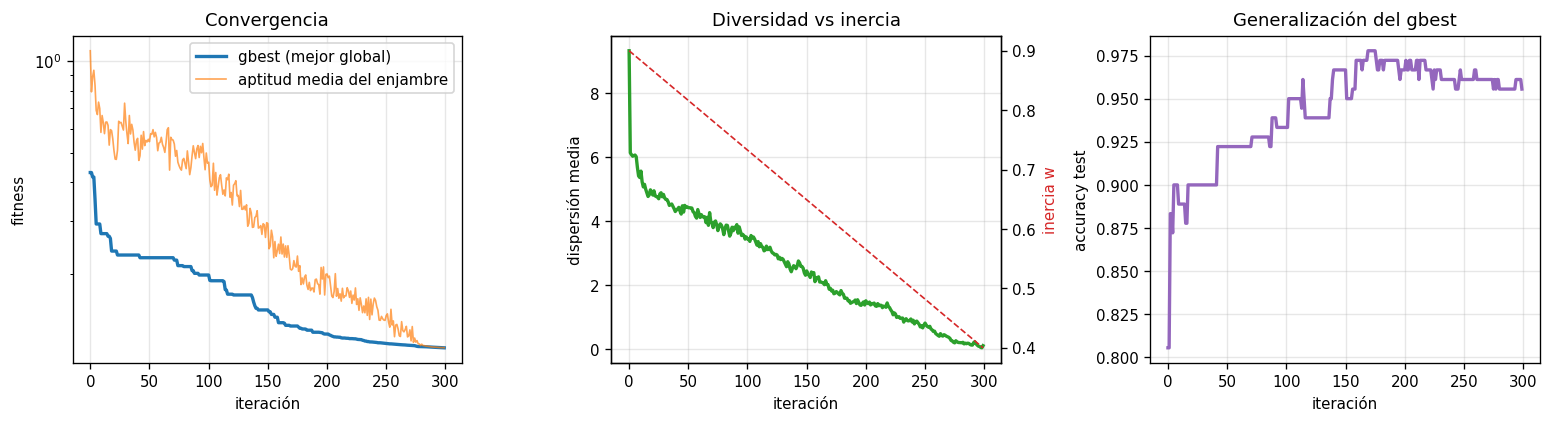

In [10]:
h = clf.pso.history
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

ax[0].plot(h["gbest"], lw=2, label="gbest (mejor global)")
ax[0].plot(h["mean"], lw=1, alpha=.7, label="aptitud media del enjambre")
ax[0].set_yscale("log"); ax[0].set_xlabel("iteración"); ax[0].set_ylabel("fitness")
ax[0].set_title("Convergencia"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(h["diversity"], color="tab:green", lw=2)
ax[1].set_xlabel("iteración"); ax[1].set_ylabel("dispersión media")
ax[1].set_title("Diversidad vs inercia"); ax[1].grid(alpha=.3)
a2 = ax[1].twinx(); a2.plot(h["w"], "--", color="tab:red", lw=1)
a2.set_ylabel("inercia w", color="tab:red")

ax[2].plot(clf.val_curve_, color="tab:purple", lw=2)
ax[2].set_xlabel("iteración"); ax[2].set_ylabel("accuracy test")
ax[2].set_title("Generalización del gbest"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## 6 · Comparación contra backpropagation

Entrenamos **la misma arquitectura** con SGD + momentum. Sirve solo como referencia:
el método propuesto no lo utiliza en ningún momento.

In [11]:
def train_backprop(X, y, hidden=(8, 6), lr=0.1, epochs=3000, seed=0):
    """Referencia con gradientes. NO forma parte del método propuesto."""
    rng = np.random.default_rng(seed)
    sizes = [X.shape[1], *hidden, 1]
    Ws, bs, vW, vb = [], [], [], []
    for i in range(len(sizes) - 1):
        lim = np.sqrt(6 / (sizes[i] + sizes[i + 1]))
        Ws.append(rng.uniform(-lim, lim, (sizes[i], sizes[i + 1])))
        bs.append(np.zeros(sizes[i + 1]))
        vW.append(np.zeros_like(Ws[-1])); vb.append(np.zeros_like(bs[-1]))
    y = y.reshape(-1, 1); hist = []
    for _ in range(epochs):
        A = [X]
        for k in range(len(Ws)):
            Z = A[-1] @ Ws[k] + bs[k]
            A.append(np.tanh(Z) if k < len(Ws) - 1 else sigmoid(Z))
        p = np.clip(A[-1], 1e-9, 1 - 1e-9)
        hist.append(float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))))
        d = (A[-1] - y) / len(X)
        for k in reversed(range(len(Ws))):
            gW, gb = A[k].T @ d, d.sum(0)
            if k > 0:
                d = (d @ Ws[k].T) * (1 - A[k] ** 2)
            vW[k] = 0.9 * vW[k] - lr * gW; Ws[k] += vW[k]
            vb[k] = 0.9 * vb[k] - lr * gb; bs[k] += vb[k]
    flat = np.concatenate([np.concatenate([W.ravel(), b]) for W, b in zip(Ws, bs)])
    return flat, hist


t0 = time.time(); w_bp, hist_bp = train_backprop(Xtr, ytr); t_bp = time.time() - t0
net = clf.net
print(f"PSO       -> BCE {clf.loss_:.4f} | train {clf.score(Xtr, ytr):.4f} "
      f"| test {clf.score(Xte, yte):.4f} | {t_pso:.2f}s")
print(f"Backprop  -> BCE {hist_bp[-1]:.4f} | train "
      f"{accuracy_binary(w_bp, net, Xtr, ytr):.4f} | test "
      f"{accuracy_binary(w_bp, net, Xte, yte):.4f} | {t_bp:.2f}s")

PSO       -> BCE 0.1149 | train 0.9595 | test 0.9556 | 6.57s
Backprop  -> BCE 0.0941 | train 0.9619 | test 0.9389 | 2.28s


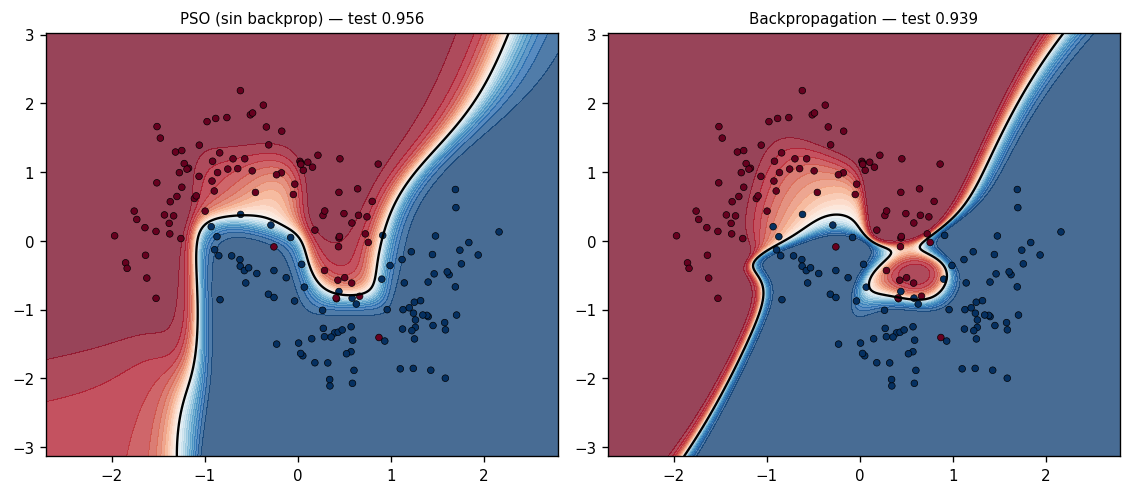

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
xx, yy = np.meshgrid(np.linspace(Xtr[:, 0].min()-.6, Xtr[:, 0].max()+.6, 300),
                     np.linspace(Xtr[:, 1].min()-.6, Xtr[:, 1].max()+.6, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
for a, (vec, ttl) in zip(axes, [
        (clf.w_,  f"PSO (sin backprop) — test {clf.score(Xte, yte):.3f}"),
        (w_bp,    f"Backpropagation — test {accuracy_binary(w_bp, net, Xte, yte):.3f}")]):
    Z = net.forward(grid, vec).reshape(xx.shape)
    a.contourf(xx, yy, Z, levels=25, cmap="RdBu", alpha=.75)
    a.contour(xx, yy, Z, levels=[.5], colors="k", linewidths=1.4)
    a.scatter(Xte[:, 0], Xte[:, 1], c=yte, cmap="RdBu", edgecolor="k", s=16, lw=.4)
    a.set_title(ttl, fontsize=9)
plt.tight_layout(); plt.show()

---
## 7 · Experimento 2 — multiclase (Iris), MLP `4-10-6-3`

La misma maquinaria, cambiando solo la activación de salida (softmax) y la aptitud
(entropía cruzada categórica). El enjambre ahora navega **137 dimensiones**.

In [13]:
d = load_iris()
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(d.data, d.target, test_size=0.3,
                                              random_state=1, stratify=d.target)
sci = StandardScaler().fit(Xi_tr)
Xi_tr, Xi_te = sci.transform(Xi_tr), sci.transform(Xi_te)

clf_i = PSOClassifier(hidden=(10, 6), task="multiclass", seed=3,
                      n_particles=45, max_iter=250, bounds=(-2.5, 2.5),
                      patience=70, verbose_every=50).fit(Xi_tr, yi_tr)

print(f"\nD = {clf_i.net.n_params} | fitness {clf_i.loss_:.4f}")
print(f"train {clf_i.score(Xi_tr, yi_tr):.4f} | test {clf_i.score(Xi_te, yi_te):.4f}")

  iter    0 | gbest=0.76859 | media=2.27905 | w=0.900 | div=11.822
  iter   50 | gbest=0.07970 | media=0.37470 | w=0.800 | div=4.841
  iter  100 | gbest=0.05469 | media=0.17165 | w=0.699 | div=3.610
  iter  150 | gbest=0.03815 | media=0.13186 | w=0.599 | div=2.976
  iter  200 | gbest=0.03130 | media=0.08769 | w=0.498 | div=1.530

D = 137 | fitness 0.0100
train 1.0000 | test 1.0000


---
## 8 · Estudio del optimizador

Pregunta: **¿cómo afectan los hiperparámetros del enjambre a la calidad de la red?**
Cada configuración se corre con 5 semillas para separar la señal del ruido estocástico.

In [14]:
configs = [
    ("N=10  w:0.9->0.4",  dict(n_particles=10, w_max=0.9, w_min=0.4, c1=1.7, c2=1.7)),
    ("N=25  w:0.9->0.4",  dict(n_particles=25, w_max=0.9, w_min=0.4, c1=1.7, c2=1.7)),
    ("N=40  w:0.9->0.4",  dict(n_particles=40, w_max=0.9, w_min=0.4, c1=1.7, c2=1.7)),
    ("N=40  w fija 0.72", dict(n_particles=40, w_max=0.72, w_min=0.72, c1=1.49, c2=1.49)),
    ("N=40  solo social", dict(n_particles=40, w_max=0.9, w_min=0.4, c1=0.2, c2=3.2)),
    ("N=40  solo cognit", dict(n_particles=40, w_max=0.9, w_min=0.4, c1=3.2, c2=0.2)),
]

tabla = []
for name, kw in configs:
    accs, fits = [], []
    for s in range(5):
        c = PSOClassifier(hidden=(8, 6), task="binary", seed=s, max_iter=200,
                          bounds=(-2.5, 2.5), patience=200, **kw).fit(Xtr, ytr)
        accs.append(c.score(Xte, yte)); fits.append(c.loss_)
    tabla.append((name, np.mean(fits), np.std(fits), np.mean(accs), np.std(accs)))
    print(f"{name:20s} fitness={np.mean(fits):.4f}±{np.std(fits):.4f}   "
          f"test acc={np.mean(accs):.4f}±{np.std(accs):.4f}")

N=10  w:0.9->0.4     fitness=0.1221±0.0069   test acc=0.9633±0.0090
N=25  w:0.9->0.4     fitness=0.1166±0.0042   test acc=0.9556±0.0061
N=40  w:0.9->0.4     fitness=0.1136±0.0041   test acc=0.9522±0.0044
N=40  w fija 0.72    fitness=0.1156±0.0070   test acc=0.9511±0.0089
N=40  solo social    fitness=0.1147±0.0043   test acc=0.9522±0.0103
N=40  solo cognit    fitness=0.1575±0.0205   test acc=0.9389±0.0149


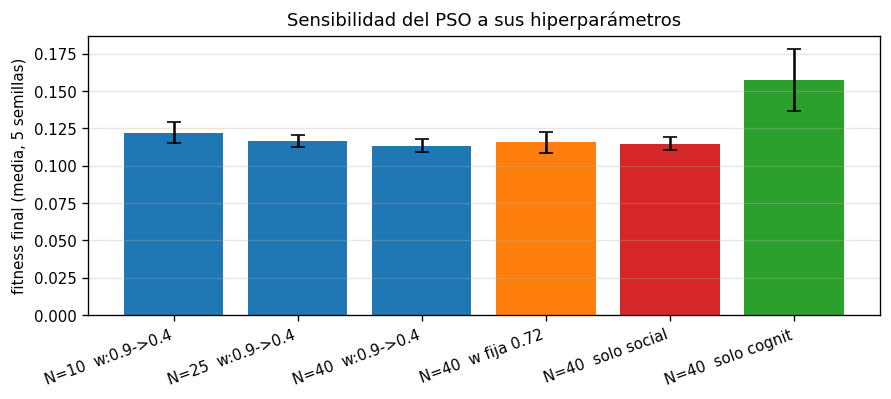

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
names = [t[0] for t in tabla]
ax.bar(range(len(tabla)), [t[1] for t in tabla], yerr=[t[2] for t in tabla],
       capsize=4, color=["tab:blue"]*3 + ["tab:orange", "tab:red", "tab:green"])
ax.set_xticks(range(len(tabla))); ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylabel("fitness final (media, 5 semillas)")
ax.set_title("Sensibilidad del PSO a sus hiperparámetros"); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

---
## 9 · Conclusiones

1. **Sí se puede entrenar una MLP de 3 capas sin backpropagation.** El enjambre halló los 85
   pesos y bias de `2-8-6-1` alcanzando ~95–96 % de accuracy en prueba, equivalente o
   ligeramente superior a la misma red entrenada con gradientes.
2. **La representación importa.** Aplanar la red a un vector convierte el entrenamiento en
   optimización continua de caja negra; el mismo código sirve para binario y multiclase con
   solo cambiar activación de salida y aptitud.
3. **La componente social es la que hace el trabajo.** Quitarla (`solo cognitivo`) degrada
   claramente el fitness y aumenta la varianza: sin comunicación, el enjambre es solo un
   conjunto de búsquedas aleatorias independientes.
4. **Limitación honesta:** el costo crece con $D$. Para redes con miles de parámetros, PSO deja
   de ser competitivo frente a backpropagation, que aprovecha la estructura diferenciable del
   problema. PSO brilla donde el gradiente no existe o no es confiable: funciones no
   diferenciables, activaciones escalonadas, o cuando además se optimiza la arquitectura.
